#### Case 1: Flux Vertical Tank
This notebook sets up the isobaric evaporation of liquid hydrogen ($LH_2$) 

In [ ]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

#### Setup tank and cryogen properties

In [2]:
# Parameters of the cylindrical liquid hydrogen tank (MHTB) in the experiment
# Presión atmosférica de operación
P = 101300.0  # Pa

# Temperatura ambiente adoptada para convertir q'' en U
T_air = 293.15  # K

# Geometría cilíndrica de Wang y Mérida
V_tank = 4.89   # m^3
d_i = 1.676     # m
d_o = d_i       # m
L_tank = 2.217  # m

# Condiciones de la comprobación inicial
LF = 0.95
eta_w = 0.97

# Condiciones térmicas adicionales
Q_roof = 0.0          # W
Q_b_horizontal = 0.0  # W

# Fluxes prescritos por Wang y Mérida
q_targets = [0.5, 1.0, 2.0]  # W/m^2

In [3]:
# Initialise cryogen
hydrogen = Cryogen(name = "hydrogen")
hydrogen.set_coolprops(P)

T_sat = hydrogen.T_sat  # K
delta_T_initial = T_air - T_sat   # K

print(f"Temperatura de saturación  = {T_sat:.8f} K")
print(f"Diferencia inicial de T    = {delta_T_initial:.8f} K")

U_values = []

print("=" * 55)
print("Coeficientes globales equivalentes")
print("=" * 55)

for q_target in q_targets:
    U = q_target / delta_T_initial
    U_values.append(U)

print(f"los valores reconstruidos a partir de {q_targets[0]} resultan en un coeficiente global de transferencia de calor de {U_values[0]:.5f} W/m^2·K")
print(f"los valores reconstruidos a partir de {q_targets[1]} resultan en un coeficiente global de transferencia de calor de {U_values[1]:.5f} W/m^2·K")
print(f"los valores reconstruidos a partir de {q_targets[2]} resultan en un coeficiente global de transferencia de calor de {U_values[2]:.5f} W/m^2·K")


Temperatura de saturación  = 20.36806760 K
Diferencia inicial de T    = 272.78193240 K
Coeficientes globales equivalentes
los valores reconstruidos a partir de 0.5 resultan en un coeficiente global de transferencia de calor de 0.00183 W/m^2·K
los valores reconstruidos a partir de 1.0 resultan en un coeficiente global de transferencia de calor de 0.00367 W/m^2·K
los valores reconstruidos a partir de 2.0 resultan en un coeficiente global de transferencia de calor de 0.00733 W/m^2·K


In [4]:
# Construccion del tanque vertical
vertical_tank = Tank(d_i=d_i,d_o=d_o,V=V_tank,vapour_geometry="cylindrical",liquid_geometry="cylindrical",LF=LF)

# Hydrogen properties for the vertical tank

vertical_hydrogen = Cryogen(name="hydrogen")
vertical_hydrogen.set_coolprops(P)

vertical_tank.cryogen = vertical_hydrogen


# CASO DE PRUEBA: q'' = 0.5 W/m²
q_target_test = q_targets[0]
U_test = U_values[0]

print(f"Flux objetivo = {q_target_test:.6f} W/m^2")
print(f"U equivalente = {U_test:.10f} W/(m^2 K)")

# PROPIEDADES DE TRANSFERENCIA DE CALOR
vertical_tank.set_HeatTransProps(U_L=U_test,U_V=U_test,T_air=T_air,Q_b_fixed=None,Q_roof=Q_roof,eta_w=eta_w)


Flux objetivo = 0.500000 W/m^2
U equivalente = 0.0018329660 W/(m^2 K)


In [7]:

# AREAS DEL TANQUE VERTICAL

A_cross = vertical_tank.A_T
A_L_vertical = vertical_tank.A_L
A_V_vertical = vertical_tank.A_V

A_total_vertical = A_L_vertical + A_cross+ A_V_vertical


#print(f"Área transversal, A_T        = {A_cross:.8f} m^2")
#print(f"Área de pared mojada, A_L    = {A_L_vertical:.8f} m^2")
#print(f"Área en contacto con vapor   = {A_V_vertical:.8f} m^2")
#print(f"Área exterior total          = {A_total_vertical:.8f} m^2")

# CALORES INICIALES DEL TANQUE VERTICAL

Q_L_in_vertical = vertical_tank.Q_L_in
Q_b_vertical = vertical_tank.Q_b
Q_wi_vertical = vertical_tank.Q_wi


#print(f"Q_L_in = {Q_L_in_vertical:.10f} W")
#print(f"Q_b    = {Q_b_vertical:.10f} W")
#print(f"Q_wi   = {Q_wi_vertical:.10f} W")


# FLUXES INICIALES DEL TANQUE VERTICAL

# Flux por la pared lateral mojada
q_L_side = Q_L_in_vertical / A_L_vertical

# Flux por el fondo
q_bottom = Q_b_vertical / A_cross

# Flux promedio sobre toda la zona mojada
q_L_total = (Q_L_in_vertical + Q_b_vertical) / (A_L_vertical + A_cross)

# Acta como me dijo el profe 
q_acta_literal = Q_L_in_vertical/ (A_L_vertical + A_cross)

# Flux que llega directamente a la interfase desde la pared seca
q_wi = Q_wi_vertical / A_V_vertical

# Flux de pared antes de aplicar la partición eta_w
q_V_before_partition = Q_wi_vertical/ (eta_w * A_V_vertical)

print("FLUXES INICIALES DEL TANQUE VERTICAL")
print("-" * 65)
print(f"q objetivo                         = {q_target_test:.10f} W/m²")
print(f"Q_L_in / A_L                      = {q_L_side:.10f} W/m²")
print(f"Q_b / A_T                         = {q_bottom:.10f} W/m²")
print(f"(Q_L_in + Q_b)/(A_L + A_T)       = {q_L_total:.10f} W/m²")
print(f"Q_L_in/(A_L + A_T), acta literal = {q_acta_literal:.10f} W/m²")
print(f"Q_wi / A_V                        = {q_wi:.10f} W/m²")
print(f"Q_wi /(eta_w A_V)                 = {q_V_before_partition:.10f} W/m²")

FLUXES INICIALES DEL TANQUE VERTICAL
-----------------------------------------------------------------
q objetivo                         = 0.5000000000 W/m²
Q_L_in / A_L                      = 0.5000000000 W/m²
Q_b / A_T                         = 0.5000000000 W/m²
(Q_L_in + Q_b)/(A_L + A_T)       = 0.5000000000 W/m²
Q_L_in/(A_L + A_T), acta literal = 0.4170195344 W/m²
Q_wi / A_V                        = 0.4850000000 W/m²
Q_wi /(eta_w A_V)                 = 0.5000000000 W/m²


#### Case 2: Flux Horizontal Tank

In [22]:
# CONSTRUCCIÓN DEL TANQUE CILÍNDRICO HORIZONTAL

horizontal_tank = Tank(d_i=d_i,d_o=d_o,V=V_tank,vapour_geometry="horizontal",liquid_geometry="horizontal",LF=LF,L=L_tank)

# PROPIEDADES DEL HIDRÓGENO PARA EL TANQUE HORIZONTAL

horizontal_hydrogen = Cryogen(name="hydrogen")
horizontal_hydrogen.set_coolprops(P)

horizontal_tank.cryogen = horizontal_hydrogen


# PROPIEDADES DE TRANSFERENCIA DE CALOR
horizontal_tank.set_HeatTransProps(U_L=U_test,U_V=U_test,T_air=T_air,Q_b_fixed=0.0,Q_roof=Q_roof,eta_w=eta_w)

In [ ]:

# GEOMETRÍA INICIAL DEL TANQUE HORIZONTAL

z_horizontal = horizontal_tank.z
l_V_horizontal = horizontal_tank.l_V

A_T_horizontal = horizontal_tank.A_T
A_L_horizontal = horizontal_tank.A_L
A_V_horizontal = horizontal_tank.A_V

A_total_horizontal =  A_L_horizontal + A_V_horizontal

print("GEOMETRÍA DEL TANQUE HORIZONTAL")
print("=" * 60)

print(f"Altura total, l             = {horizontal_tank.l:.8f} m^2")

print(f"Altura de líquido, z        ={z_horizontal:.8f} m^2")

print(f"Altura del vapor, l_V       = {l_V_horizontal:.8f} m^2")

print(f"Área interfacial, A_T       = {A_T_horizontal:.8f} m^2")

print(f"Área de pared mojada, A_L   = {A_L_horizontal:.8f} m^2")

print(f"Área en contacto con vapor  = {A_V_horizontal:.8f} m^2")

print(f"Área exterior total         = {A_total_horizontal:.8f} m^2")



# CALORES INICIALES DEL TANQUE HORIZONTAL
Q_L_in_horizontal = horizontal_tank.Q_L_in
Q_b_horizontal_result = horizontal_tank.Q_b
Q_wi_horizontal = horizontal_tank.Q_wi

print("CALORES INICIALES DEL TANQUE HORIZONTAL")
print("-" * 60)

print(f"Q_L_in = {Q_L_in_horizontal:.10f} W")

print(f"Q_b    = {Q_b_horizontal_result:.10f} W")

print(f"Q_wi   = {Q_wi_horizontal:.10f} W")


GEOMETRÍA DEL TANQUE HORIZONTAL
Altura total, l             = 1.67600000 m
Altura de líquido, z        = 1.00283319 m
Altura del vapor, l_V       = 0.67316681 m
Área interfacial, A_T       = 3.64310246 m²
Área de pared mojada, A_L   = 11.85248951 m²
Área en contacto con vapor  = 4.23303037 m²
Área exterior total         = 16.08551987 m²
CALORES INICIALES DEL TANQUE HORIZONTAL
Q_L_in = 5.9262447538 W
Q_b    = 0.0000000000 W
Q_wi   = 2.0530197273 W


In [ ]:
# FLUXES INICIALES DEL TANQUE HORIZONTAL

# Flux hacia toda la pared mojada
q_L_horizontal = Q_L_in_horizontal/ A_L_horizontal

# Como no hay flujo inferior separado:
q_L_total_horizontal = (Q_L_in_horizontal + Q_b_horizontal_result) / A_L_horizontal

# Flux que llega desde la pared de vapor a la interfase
q_wi_horizontal = Q_wi_horizontal/ A_V_horizontal

# Flux antes de aplicar la partición eta_w
q_V_before_partition_horizontal = Q_wi_horizontal/ (eta_w * A_V_horizontal)

print("FLUXES INICIALES DEL TANQUE HORIZONTAL")
print("-" * 65)

print(f"q objetivo                         = {q_target_test:.10f} W/m^2")

print(f"Q_L_in / A_L                      = {q_L_horizontal:.10f} W/m^2")

print(f"(Q_L_in + Q_b) / A_L             = {q_L_total_horizontal:.10f} W/m^2")

print(f"Q_wi / A_V                        = {q_wi_horizontal:.10f} W/m^2")

print(f"Q_wi / (eta_w A_V)                = {q_V_before_partition_horizontal:.10f} W/m^2")

FLUXES INICIALES DEL TANQUE HORIZONTAL
q objetivo                         = 0.5000000000 W/m²
Q_L_in / A_L                      = 0.5000000000 W/m²
(Q_L_in + Q_b) / A_L             = 0.5000000000 W/m²
Q_wi / A_V                        = 0.4850000000 W/m²
Q_wi / (eta_w A_V)                = 0.5000000000 W/m²


### A partir de aquí se usará una función para automatizar el cálculo de los flux para los $U$

In [27]:
# FUNCIÓN PARA CONSTRUIR Y CONFIGURAR UN TANQUE

def configure_tank(orientation, U_value):

    if orientation == "vertical":
        tank = Tank(
            d_i=d_i,
            d_o=d_o,
            V=V_tank,
            vapour_geometry="cylindrical",
            liquid_geometry="cylindrical",
            LF=LF
        )

        # En vertical, el fondo se calcula por separado.
        Q_b_fixed = None

    elif orientation == "horizontal":
        tank = Tank(
            d_i=d_i,
            d_o=d_o,
            V=V_tank,
            vapour_geometry="horizontal",
            liquid_geometry="horizontal",
            LF=LF,
            L=L_tank
        )

        # En horizontal no agregamos una fuente inferior adicional.
        Q_b_fixed = 0.0

    else:
        raise ValueError(
            "orientation debe ser 'vertical' o 'horizontal'."
        )

    # Cada tanque recibe un objeto Cryogen independiente.
    cryogen = Cryogen(name="hydrogen")
    cryogen.set_coolprops(P)

    tank.cryogen = cryogen

    tank.set_HeatTransProps(
        U_L=U_value,
        U_V=U_value,
        T_air=T_air,
        Q_b_fixed=Q_b_fixed,
        Q_roof=Q_roof,
        eta_w=eta_w
    )

    return tank

In [ ]:
# FUNCIÓN PARA EXTRAER CALORES Y FLUXES
def calculate_initial_fluxes(tank, orientation):
    """
    Calcula áreas, calores y fluxes iniciales para un tanque
    ya configurado.
    """

    Q_L_in = tank.Q_L_in
    Q_b = tank.Q_b
    Q_wi = tank.Q_wi

    if orientation == "vertical":
        # A_L contiene solo la pared lateral mojada.
        # A_T representa el fondo en este balance.
        A_wet = tank.A_L + tank.A_T
        Q_wet = Q_L_in + Q_b

    elif orientation == "horizontal":
        # A_L pretende contener toda la pared mojada.
        A_wet = tank.A_L
        Q_wet = Q_L_in + Q_b

    else:
        raise ValueError("orientation debe ser 'vertical' o 'horizontal'.")

    q_liquid = Q_wet / A_wet
    q_wi = Q_wi / tank.A_V
    q_vapour_before_partition = Q_wi / (eta_w * tank.A_V)

# Suma de los términos de pared asignados inicialmente
# a la región líquida/interfacial. Q_VL no se incluye
# porque no está siendo calculado en esta verificación estática.
    Q_total_initial_to_liquid = Q_wet + Q_wi

    return {
        "orientation": orientation,
        "A_L": tank.A_L,
        "A_V": tank.A_V,
        "A_T": tank.A_T,
        "Q_L_in": Q_L_in,
        "Q_b": Q_b,
        "Q_wi": Q_wi,
        "Q_wet": Q_wet,
        "Q_total_initial": Q_total_initial_to_liquid,
        "q_liquid": q_liquid,
        "q_wi": q_wi,
        "q_vapour_before_partition": q_vapour_before_partition,
    }

In [30]:
# VERIFICACIÓN PARA LOS TRES FLUXES Y DOS GEOMETRÍAS

flux_results = []

for q_target, U_value in zip(q_targets, U_values):

    for orientation in ["vertical", "horizontal"]:

        tank = configure_tank(orientation=orientation,U_value=U_value)

        result = calculate_initial_fluxes(tank=tank,orientation=orientation)

        result["q_target"] = q_target
        result["U"] = U_value

        flux_results.append(result)

In [ ]:
# RESUMEN DE RESULTADOS

header = (
    f"{'Geometría':<12}"
    f"{'q obj.':>10}"
    f"{'U':>10}"
    f"{'q líquido':>18}"
    f"{'Qwi/Av':>14}"
    f"{'Qwi/(eta Av)':>17}"
    f"{'Q líquido':>14}"
    f"{'Qwi':>9}"
)

print(header)
print("-" * len(header))

for result in flux_results:
    print(
        f"{result['orientation']:<12}"
        f"{result['q_target']:>10.3f}"
        f"{result['U']:>14.8f}"
        f"{result['q_liquid']:>14.6f}"
        f"{result['q_wi']:>14.6f}"
        f"{result['q_vapour_before_partition']:>16.6f}"
        f"{result['Q_wet']:>14.6f}"
        f"{result['Q_wi']:>12.6f}"
    )

Geometría       q obj.         U         q líquido        Qwi/Av     Qwi/(eta Av)     Q líquido      Qwi
--------------------------------------------------------------------------------------------------------
vertical         0.500    0.00183297      0.500000      0.485000        0.500000      6.646638    1.353003
horizontal       0.500    0.00183297      0.500000      0.485000        0.500000      5.926245    2.053020
vertical         1.000    0.00366593      1.000000      0.970000        1.000000     13.293277    2.706006
horizontal       1.000    0.00366593      1.000000      0.970000        1.000000     11.852490    4.106039
vertical         2.000    0.00733186      2.000000      1.940000        2.000000     26.586554    5.412012
horizontal       2.000    0.00733186      2.000000      1.940000        2.000000     23.704979    8.212079


In [64]:
vertical_results = [
    result
    for result in flux_results
    if result["orientation"] == "vertical"
]

horizontal_results = [
    result
    for result in flux_results
    if result["orientation"] == "horizontal"
]

vertical_results = sorted(
    vertical_results,
    key=lambda result: result["q_target"]
)

horizontal_results = sorted(
    horizontal_results,
    key=lambda result: result["q_target"]
)

#print("Casos verticales:", len(vertical_results))
#print("Casos horizontales:", len(horizontal_results))

#Fluxes objetivo 
q_vertical = [
    result["q_target"]
    for result in vertical_results
]

q_horizontal = [
    result["q_target"]
    for result in horizontal_results
]

#Q_Lin
Q_L_in_vertical = [
    result["Q_L_in"]
    for result in vertical_results
]

Q_L_in_horizontal = [
    result["Q_L_in"]
    for result in horizontal_results
]

#Q_wi
Q_wi_vertical = [
    result["Q_wi"]
    for result in vertical_results
]

Q_wi_horizontal = [
    result["Q_wi"]
    for result in horizontal_results
]

#Flux liquido 
q_liquid_vertical = [
    result["q_liquid"]
    for result in vertical_results
]

q_liquid_horizontal = [
    result["q_liquid"]
    for result in horizontal_results
]

#Flux Q_wi/A_V
q_wi_vertical = [
    result["q_wi"]
    for result in vertical_results
]

q_wi_horizontal = [
    result["q_wi"]
    for result in horizontal_results
]

#Flux antes de aplicar eta_w
q_before_partition_vertical = [
    result["q_vapour_before_partition"]
    for result in vertical_results
]

q_before_partition_horizontal = [
    result["q_vapour_before_partition"]
    for result in horizontal_results
]

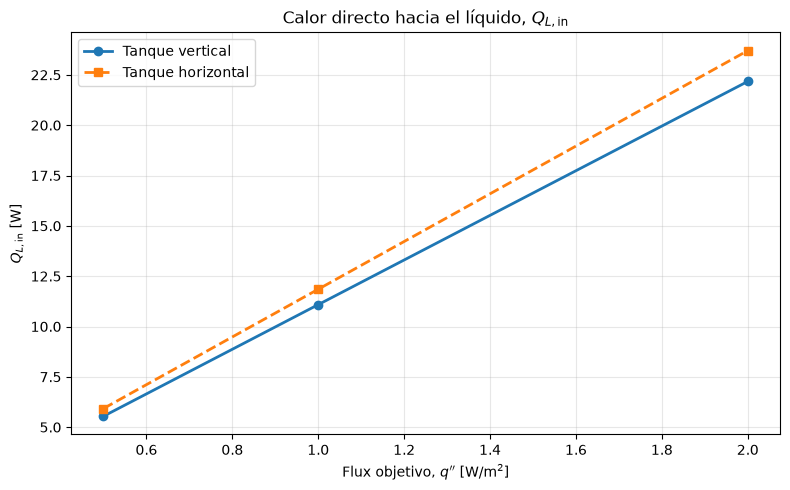

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(q_vertical,Q_L_in_vertical,marker="o",linewidth=2,label="Tanque vertical")

plt.plot(q_horizontal,Q_L_in_horizontal,marker="s",linestyle="--",linewidth=2,label="Tanque horizontal")

plt.xlabel(r"Flux objetivo, $q''$ [W/m$^2$]")
plt.ylabel(r"$Q_{L,\mathrm{in}}$ [W]")

plt.title(r"Calor directo hacia el líquido, $Q_{L,\mathrm{in}}$")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()



plt.show()

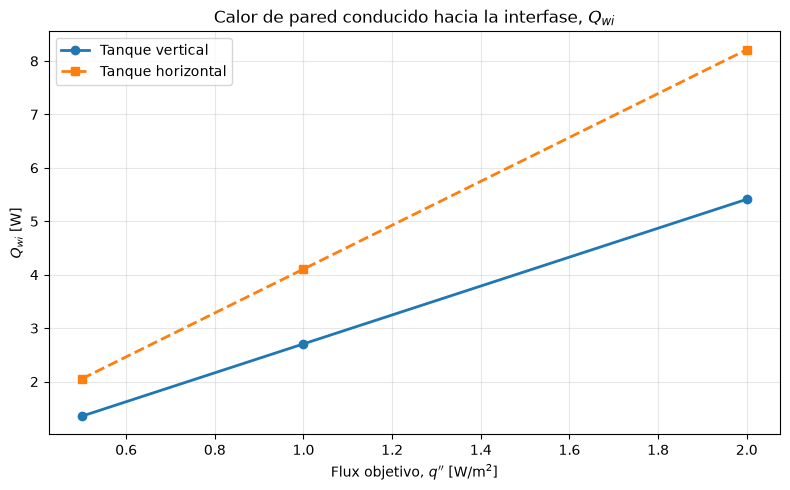

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(q_vertical,Q_wi_vertical,marker="o",linewidth=2,label="Tanque vertical")

plt.plot(q_horizontal,Q_wi_horizontal,marker="s",linestyle="--",linewidth=2,label="Tanque horizontal")

plt.xlabel(r"Flux objetivo, $q''$ [W/m$^2$]")
plt.ylabel(r"$Q_{wi}$ [W]")

plt.title(r"Calor de pared conducido hacia la interfase, $Q_{wi}$")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

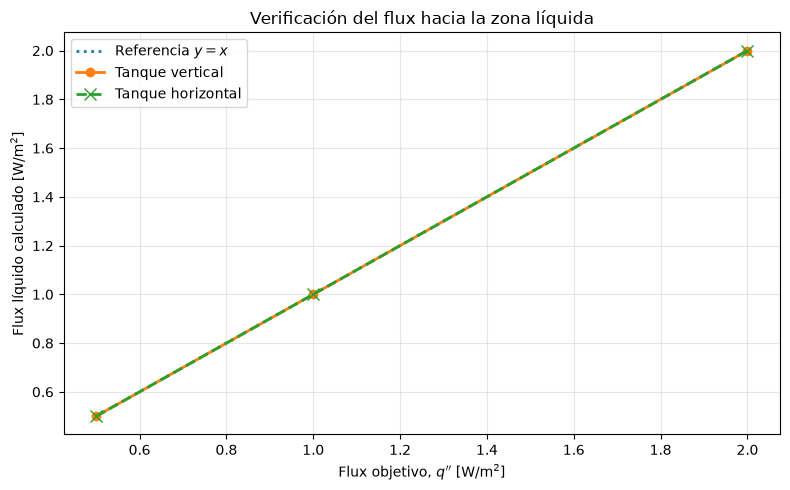

In [ ]:
plt.figure(figsize=(8, 5))

# Línea ideal de referencia
plt.plot(q_vertical,q_vertical,linestyle=":",linewidth=2,label=r"Referencia $y=x$")

plt.plot(q_vertical,q_liquid_vertical,marker="o",linewidth=2,label="Tanque vertical")

plt.plot(q_horizontal,q_liquid_horizontal,marker="x",linestyle="--",linewidth=2,markersize=8,label="Tanque horizontal")

plt.xlabel(r"Flux objetivo, $q''$ [W/m$^2$]")
plt.ylabel(r"Flux líquido calculado [W/m$^2$]")

plt.title("Verificación del flux hacia la zona líquida")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


plt.show()

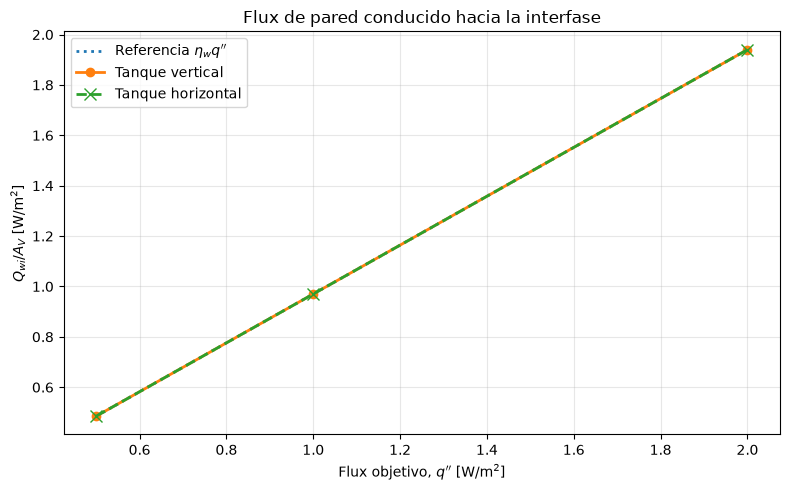

In [ ]:
q_wi_reference = [
    eta_w * q
    for q in q_vertical
]


plt.figure(figsize=(8, 5))

plt.plot(q_vertical,q_wi_reference,linestyle=":",linewidth=2,label=r"Referencia $\eta_w q''$")

plt.plot(q_vertical,q_wi_vertical,marker="o",linewidth=2,label="Tanque vertical")

plt.plot(q_horizontal,q_wi_horizontal,marker="x",linestyle="--",linewidth=2,markersize=8,label="Tanque horizontal")

plt.xlabel(r"Flux objetivo, $q''$ [W/m$^2$]")
plt.ylabel(r"$Q_{wi}/A_V$ [W/m$^2$]")

plt.title(r"Flux de pared conducido hacia la interfase")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


plt.show()

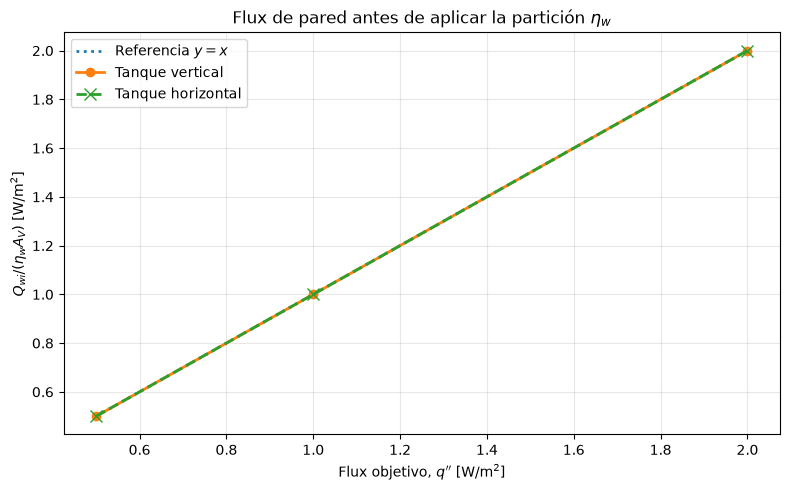

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(q_vertical,q_vertical,linestyle=":",linewidth=2,label=r"Referencia $y=x$")

plt.plot(q_vertical,q_before_partition_vertical,marker="o",linewidth=2,label="Tanque vertical")

plt.plot(q_horizontal,q_before_partition_horizontal,marker="x",linestyle="--",linewidth=2,markersize=8,label="Tanque horizontal")

plt.xlabel(r"Flux objetivo, $q''$ [W/m$^2$]")
plt.ylabel(r"$Q_{wi}/(\eta_w A_V)$ [W/m$^2$]")

plt.title(r"Flux de pared antes de aplicar la partición $\eta_w$")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


plt.show()